In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from sklearn.preprocessing import OneHotEncoder

In [ ]:
df = pd.read_csv("loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1   no_of_dependents           4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
df.shape

(4269, 13)

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [ ]:
df['loan_status']

,loan_status
0,Approved
1,Rejected
2,Rejected
3,Rejected
4,Rejected
...,...
4264,Rejected
4265,Approved
4266,Rejected
4267,Approved


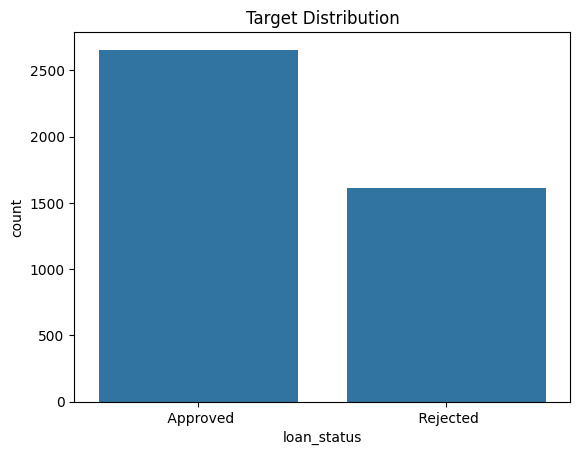

In [ ]:
sns.countplot(x='loan_status', data=df)
plt.title("Target Distribution")
plt.show()

In [ ]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
df['loan_status'].unique()

array([' Approved', ' Rejected'], dtype=object)

In [ ]:
# One hot encoding
cat_cols = ['education', 'self_employed']
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(df[cat_cols])

encoded_df = pd.DataFrame(encoded,
                          columns=encoder.get_feature_names_out(cat_cols),
                          index=df.index
                          )

df_final = pd.concat([df.drop(cat_cols, axis=1), encoded_df], axis=1)
df_final['loan_status'] = df_final['loan_status'].map({' Approved': 0, ' Rejected': 1})


In [ ]:
df = df_final
df

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_ Not Graduate,self_employed_ Yes
0,1,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,0.0,0.0
1,2,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,1.0,1.0
2,3,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1,0.0,0.0
3,4,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1,0.0,0.0
4,5,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,1000000,2300000,12,317,2800000,500000,3300000,800000,1,0.0,1.0
4265,4266,0,3300000,11300000,20,559,4200000,2900000,11000000,1900000,0,1.0,1.0
4266,4267,2,6500000,23900000,18,457,1200000,12400000,18100000,7300000,1,1.0,0.0
4267,4268,1,4100000,12800000,8,780,8200000,700000,14100000,5800000,0,1.0,0.0


In [ ]:
# Split dataset
X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
X_train.shape, y_train.shape

((3201, 12), (3201,))

In [ ]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)

rf_acc = accuracy_score(y_test, preds)
print("Random Forest Accuracy: ", rf_acc)

Random Forest Accuracy:  0.9709737827715356


In [ ]:
# Train custom bagger
from sklearn.utils import resample
from scipy.stats import mode

def bagger_fit_predict(model_fns, X_train, y_train, X_test, n_estimators=15):
  all_preds = []
  for fn in model_fns:
    for _ in range(n_estimators):
      # bootstrap sample
      X_bs, y_bs = resample(X_train, y_train, replace=True)
      # build model
      model = fn()
      # fit model
      model.fit(X_bs, y_bs)
      # predict
      preds = model.predict(X_test)
      all_preds.append(preds)
  all_preds = np.array(all_preds)
  final_preds = mode(all_preds, axis=0).mode
  return final_preds.ravel()


# ------ Bagging ensemble -------
model_list = [
    lambda: DecisionTreeClassifier(max_depth=5),
    lambda: KNeighborsClassifier(n_neighbors=5),
    lambda: LogisticRegression(max_iter=50)
]

bagger_preds = bagger_fit_predict(
    model_fns=model_list,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    n_estimators=15
)
bagger_acc = accuracy_score(y_test, bagger_preds)
print("Custom Bagger Accuracy: ", bagger_acc)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Custom Bagger Accuracy:  0.75


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

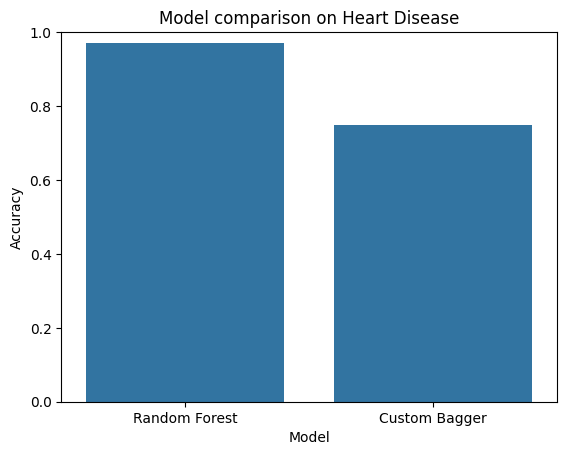

In [ ]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Custom Bagger"],
    "Accuracy": [rf_acc, bagger_acc]
})

sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model comparison on Heart Disease")
plt.ylim(0, 1)
plt.show()

In [ ]:
print ("Classification Report (Random Forest): ")
print(classification_report(y_test, preds))

Classification Report (Random Forest): 
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       672
           1       0.94      0.98      0.96       396

    accuracy                           0.97      1068
   macro avg       0.97      0.97      0.97      1068
weighted avg       0.97      0.97      0.97      1068



In [ ]:
print ("Classification Report (custom Bagger): ")
print(classification_report(y_test, bagger_preds))

Classification Report (custom Bagger): 
              precision    recall  f1-score   support

           0       0.72      1.00      0.83       672
           1       1.00      0.33      0.49       396

    accuracy                           0.75      1068
   macro avg       0.86      0.66      0.66      1068
weighted avg       0.82      0.75      0.71      1068



In [ ]:
# confusion matrix
from sklearn.metrics import confusion_matrix
cm_rf = confusion_matrix(y_test, preds)
print("Confusion Matrix Random Forest: ")
cm_rf

Confusion Matrix Random Forest: 


array([[649,  23],
       [  8, 388]])

In [ ]:
from sklearn.metrics import confusion_matrix
cm_bagger = confusion_matrix(y_test, bagger_preds)
print("Confusion Matrix (Bagging): ")
cm_bagger

Confusion Matrix (Bagging): 


array([[672,   0],
       [267, 129]])

In [ ]:
# Voting Method

from sklearn.ensemble import VotingClassifier

voting_ensemble = VotingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(max_depth=5)),
        ('knn', KNeighborsClassifier(n_neighbors=3))
    ],
    voting='hard'
)
voting_ensemble.fit(X_train, y_train)
print("Voting Ensemble Accuracy: ", voting_ensemble.score(X_test, y_test))


Voting Ensemble Accuracy:  0.7471910112359551


In [ ]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Custom Bagger", "Voting Method"],
    "Accuracy": [rf_acc, bagger_acc]
})

sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model comparison on Heart Disease")
plt.ylim(0, 1)
plt.show()